# CU-BEMS: peak electricity demand and lighting comfort
## tl;dr
**Question:** How much can peak electricity demand be reduced in each zone without compromising lighting comfort?

This notebook first investigates all seven floors and all local files, then evaluates a
**conditional lighting-only scenario** for April 2019. The executed tables quantify the
scenario; they do not demonstrate safe achievable savings. A controlled dimming trial,
task-plane lux measurements, and occupant feedback are needed to establish that claim.

**Verified finding from these local files:** the highest valid ambient-light reading is
138 lux. None of the default April zone scenarios permits dimming at a 500-lux target
with a 10% margin, so there are **no positive supported scenario reductions**. Unsupported zones have unavailable estimates, rather than an asserted zero opportunity. This does
not prove zero physical potential or task-plane noncompliance: the sensor-to-task-plane
relationship is unknown. Validate that relationship before recommending lighting reduction.

**Date correction:** the local and original CU-BEMS data cover July 2018–December 2019.
There are no 2017 files here. Do not rename 2019 observations as 2017.

Use **Restart Kernel → Run All**. Install `requirements.txt` first. Full ingestion reads
about 686 MiB sequentially and may take several minutes. All computational functions are
included below; no separate Python helper files are required.

## Context & Methods
Facilities managers benefit from a quantified shortlist for a dimming pilot; building users
benefit from explicit lighting safeguards; the university benefits from lower demand if
the trial succeeds. AC and plugs describe the demand baseline but are not controlled here.

### Key Assumptions
- Timestamps are interpreted as the building's Bangkok local clock (UTC+7), not Singapore time.
- Weekdays 08:00–18:00 are an assumed operating schedule, **not occupancy**. Holidays are not removed.
- 15-minute mean kW is the analysis demand interval; confirm the actual tariff interval before financial claims.
- 500 lux is an **illustrative office-task target**, not a verified requirement for all zones.
  Repeat at 300/500/750 lux; facilities staff must approve zone-specific task-plane requirements.
- Ambient sensor lux is a proxy, not proof of task-plane illuminance, uniformity, glare, or visual comfort.
- No observed occupancy, CO₂, particulate matter, outdoor weather, dimming commands, or post-intervention outcomes exist.
- Dimming changes lighting only; no assumed AC cooling benefit, plug curtailment, demand charge, or carbon saving is added.
- Missing values stay missing; zero power and zero lux remain valid observations. Large power spikes are flagged, not deleted.

**Fair baseline:** evaluate baseline and scenario on identical valid power intervals,
including intervals without lux (no action then). Recompute the scenario maximum over the
entire evaluation month, since shaving the original maximum can move the peak elsewhere.
Use earlier March observations for peak-trigger calibration, never April outcomes.
Annual EDA describes unequal observation periods; it is not used as a before/after savings estimate.

**Scenario formula:** `d = min(cap, max(0, 1 − target*(1+margin)/minimum_lux))` at eligible
peak intervals. `saved_kW = lighting_kW*d`; `scenario_total_kW = total_kW − saved_kW`.
The lux proxy is `minimum_lux*(1−d)`. If non-negative daylight and proportional electric-light
response hold, scaling *all* lux is conservative; these conditions require field validation.
Minimum lux is taken across available sensors and all 15 minutes; actions require all 15 minutes
of valid power and lux. The retrospective interval minimum also introduces **hindsight within
the interval**: these estimates are offline screening, not a real-time controller simulation.

Source: [Pipattanasomporn et al. (2020), Scientific Data](https://doi.org/10.1038/s41597-020-00582-3);
[original data](https://doi.org/10.6084/m9.figshare.11726517).
The paper documents sensor maintenance from September 2018 to March 2019, Floor 1 without
environment sensors, and most Zone 3 staircase areas without sensors. Actual CSV schema controls this analysis.

**Assessment gates:** all 15 minutes are required for demand; at least 80% of expected March operating intervals and 200 readings for calibration; at least 95% of expected April power intervals and 80% of expected April operating power/lux pairs for a supported zone assessment. These are analyst screening gates, not standards. Unsupported zones retain their observed baseline and a no-action trace, but their **supported reduction is unavailable (NaN)**. A zero supported reduction means no headroom under the stated rule; achieved comfort-preserving reduction remains unavailable for every zone. No physical response is fitted and no causal confidence interval is claimed.

### 1. Imports, paths, and visible parameters

In [1]:
from pathlib import Path
import os, re, json, sys
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option('display.max_columns', 16)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .18})
BLUE, GOLD, GREY = '#3274A1', '#D5A036', '#555555'
INTERVAL_MINUTES = 15
MIN_COVERAGE = 1.00  # all 15 minutes for baseline and control calculations
PILOT_FLOOR = 2
TRAIN_START, TRAIN_END = '2019-03-06', '2019-04-01'
TEST_START, TEST_END = '2019-04-01', '2019-05-01'
COMFORT_LUX, LUX_MARGIN, DIM_CAP = 500, .10, .20
PEAK_QUANTILE = .95
print({'python': sys.version.split()[0], 'pandas': pd.__version__, 'numpy': np.__version__})

{'python': '3.9.6', 'pandas': '2.3.3', 'numpy': '2.0.2'}


### 2. Inspectable functions: discovery, cleaning, aggregation, and calculations

#### `find_dataset`

In [2]:
def find_dataset(start=None):
    start = Path(start or Path.cwd()).resolve()
    for parent in [start, *start.parents]:
        for candidate in [parent / 'SBA_Kaggle_Dataset', parent]:
            if (candidate / 'data').is_dir() and list((candidate / 'data').glob('*Floor*.csv')):
                return candidate
    raise FileNotFoundError('Run from the repository or SBA_Kaggle_Dataset/Light.')

#### `parse_dates`

In [3]:
def parse_dates(series, slash_order=None):
    """Parse ISO and file-level slash dates using unambiguous >12 day evidence.

    Floor 7's local 2019 file uses day/month/year. Do not guess each row:
    4/1/19 means January 4 in that entire file, not April 1. An all-ambiguous
    slash-date file needs an explicit 'dayfirst' or 'monthfirst' override.
    """
    text = series.astype('string').str.strip()
    iso = text.str.match(r'^\d{4}-', na=False)
    out = pd.Series(pd.NaT, index=series.index, dtype='datetime64[ns]')
    out.loc[iso] = pd.to_datetime(text.loc[iso], format='ISO8601', errors='coerce')
    slash = text.str.match(r'^\d{1,2}/\d{1,2}/\d{2} ', na=False)
    if slash.any():
        pieces = text.loc[slash].str.extract(r'^(\d{1,2})/(\d{1,2})/')
        first_day_evidence = pd.to_numeric(pieces[0]).gt(12).any()
        second_day_evidence = pd.to_numeric(pieces[1]).gt(12).any()
        if slash_order is None:
            if first_day_evidence and second_day_evidence:
                raise ValueError('Mixed slash-date conventions: resolve at source.')
            if not first_day_evidence and not second_day_evidence:
                raise ValueError('Ambiguous slash-date file: specify slash_order.')
            slash_order = 'dayfirst' if first_day_evidence else 'monthfirst'
        if slash_order not in ['dayfirst', 'monthfirst']:
            raise ValueError('slash_order must be dayfirst or monthfirst')
        fmt = '%d/%m/%y %H:%M' if slash_order == 'dayfirst' else '%m/%d/%y %H:%M'
        out.loc[slash] = pd.to_datetime(text.loc[slash], format=fmt, errors='coerce')
    # Local building clock, Bangkok (UTC+7); no conversion to Singapore clock.
    return out

#### `column_metadata`

In [4]:
def column_metadata(columns, floor):
    rows = []
    for column in columns:
        match = re.fullmatch(r'z(\d+)_(.+)\((.+)\)', column)
        if match is None:
            raise ValueError(f'Unrecognised measurement column: {column}')
        zone, device, unit = match.groups()
        kind = ('ac' if device.startswith('AC') else 'light' if device == 'Light'
                else 'plug' if device == 'Plug' else
                {'lux': 'lux', 'degC': 'temperature', 'RH%': 'humidity'}.get(unit))
        if kind is None:
            raise ValueError(column)
        rows.append(dict(column=column, floor=floor, zone=int(zone),
                         zone_id=f'F{floor}-Z{zone}', device=device, unit=unit, kind=kind))
    return pd.DataFrame(rows)

#### `operating_mask`

In [5]:
def operating_mask(index, start_hour=8, end_hour=18):
    """Assumed weekday schedule, not observed occupancy or holiday calendar."""
    return (index.dayofweek < 5) & (index.hour >= start_hour) & (index.hour < end_hour)

#### `load_all`

In [6]:
def load_all(data_dir, interval_minutes=15, coverage=0.90,
             pilot_floor=2, pilot_start='2019-04-01', pilot_end='2019-05-01'):
    """Load one floor-file at a time; retain compact interval data and one pilot month.

    Strict zone power sum: every installed/available circuit must be valid at
    the SAME minute. Missing circuit != zero. Absent AC/plug is structurally zero
    only within the observed circuit schema; completeness is not a billing audit.
    Duplicated timestamps are quarantined in entirety, including exact copies.
    Reindex only the advertised year coverage to reveal missing minutes.
    """
    required = int(np.ceil(interval_minutes * coverage))
    interval = f'{interval_minutes}min'
    zone_frames, file_rows, quality_rows, schemas, pilots = [], [], [], [], []
    files = sorted(Path(data_dir).glob('*Floor*.csv'))
    if not files:
        raise FileNotFoundError(data_dir)
    for path in files:
        match = re.fullmatch(r'(\d{4})Floor([1-7])\.csv', path.name)
        if match is None:
            continue
        year, floor = map(int, match.groups())
        raw = pd.read_csv(path, low_memory=False)
        raw.columns = raw.columns.str.strip()
        if 'Date' not in raw:
            raise ValueError(f'{path.name}: missing Date')
        date_text = raw.pop('Date')
        dates = parse_dates(date_text)
        metadata = column_metadata(raw.columns, floor)
        metadata['file'] = path.name
        schemas.append(metadata)
        numeric = raw.apply(pd.to_numeric, errors='coerce')
        invalid_date = dates.isna()
        off_minute = dates.notna() & (dates != dates.dt.floor('min'))
        duplicate = dates.notna() & dates.duplicated(keep=False)
        start = pd.Timestamp(f'{year}-07-01' if year == 2018 else f'{year}-01-01')
        end = pd.Timestamp(f'{year+1}-01-01')
        outside = dates.notna() & ((dates < start) | (dates >= end))
        bad_values = {}
        for row in metadata.itertuples():
            values = numeric[row.column]
            bad = ~np.isfinite(values) & values.notna()
            if row.kind in ['ac', 'light', 'plug', 'lux']:
                bad |= values < 0
            if row.kind == 'lux':
                bad |= values > 10000  # documented sensor range
            if row.kind == 'humidity':
                bad |= (values < 0) | (values > 100)
            if row.kind == 'temperature':
                bad |= (values < 0) | (values > 90)  # hardware range, not comfort band
            bad_values[row.column] = bad
            numeric.loc[bad, row.column] = np.nan
        keep = ~(invalid_date | off_minute | duplicate | outside)
        clean = numeric.loc[keep].copy()
        clean.index = pd.DatetimeIndex(dates.loc[keep], name='timestamp')
        clean = clean.sort_index()
        expected = pd.date_range(start, end, freq='min', inclusive='left', name='timestamp')
        file_rows.append(dict(file=path.name, floor=floor, filename_year=year,
                              raw_rows=len(raw), invalid_dates=int(invalid_date.sum()),
                              duplicate_rows_quarantined=int(duplicate.sum()),
                              off_minute_rows=int(off_minute.sum()), outside_period_rows=int(outside.sum()),
                              actual_start=dates.min(), actual_end=dates.max(),
                              timestamps_monotonic_before_cleaning=bool(dates.dropna().is_monotonic_increasing),
                              expected_minutes=len(expected), usable_rows=len(clean),
                              missing_timestamp_minutes=len(expected)-len(clean)))
        for row in metadata.itertuples():
            values = clean[row.column]
            q1, q3 = values.quantile([.25, .75])
            fence = q3 + 3*(q3-q1)
            quality_rows.append(dict(file=path.name, floor=floor, zone=row.zone, zone_id=row.zone_id,
                                     column=row.column, kind=row.kind, expected_minutes=len(expected),
                                     valid_minutes=int(values.notna().sum()),
                                     missing_fraction=1-values.notna().sum()/len(expected),
                                     invalid_values_masked=int(bad_values[row.column].sum()),
                                     numeric_parse_failures=int((raw[row.column].notna() &
                                                                pd.to_numeric(raw[row.column], errors='coerce').isna()).sum()),
                                     zero_fraction=values.eq(0).sum()/max(values.notna().sum(), 1),
                                     unique_values=values.nunique(), minimum=values.min(),
                                     median=values.median(), p99=values.quantile(.99), maximum=values.max(),
                                     high_outlier_flags=int(values.gt(fence).sum()),
                                     constant_run_pairs=int((values.eq(values.shift()) &
                                         (values.index.to_series().diff() == pd.Timedelta(minutes=1))).sum())))
        clean = clean.reindex(expected).astype('float32')
        for zone, spec in metadata.groupby('zone'):
            minute = pd.DataFrame(index=expected)
            for kind in ['ac', 'light', 'plug']:
                cols = spec.loc[spec.kind.eq(kind), 'column'].tolist()
                minute[f'{kind}_kw'] = clean[cols].sum(axis=1, min_count=len(cols)) if cols else 0.0
            power_columns = spec.loc[spec.kind.isin(['ac', 'light', 'plug']), 'column'].tolist()
            minute['total_kw'] = clean[power_columns].sum(axis=1, min_count=len(power_columns))
            for kind in ['lux', 'temperature', 'humidity']:
                cols = spec.loc[spec.kind.eq(kind), 'column'].tolist()
                # Minimum across lux sensors; average across temperature/RH sensors.
                values = clean[cols].min(axis=1) if kind == 'lux' else clean[cols].mean(axis=1)
                if cols:
                    values = values.where(clean[cols].notna().all(axis=1))
                minute[kind] = values if cols else np.nan
            # Demand interval averages (kW), never sum kW across minutes as demand.
            grouped = minute.resample(interval, label='left', closed='left')
            counts = grouped.count()
            agg = grouped.mean().where(counts >= required)
            # Components must average the SAME supported minutes as total demand.
            common_power = minute[['ac_kw', 'light_kw', 'plug_kw']].where(
                minute.total_kw.notna(), axis=0)
            agg[['ac_kw', 'light_kw', 'plug_kw']] = common_power.resample(interval).mean().where(
                counts.total_kw.ge(required), axis=0)
            agg['lux_min'] = grouped['lux'].min().where(counts['lux'] == interval_minutes)
            agg['lux_valid_minutes'] = counts['lux']
            agg['power_valid_minutes'] = counts['total_kw']
            agg['light_valid_minutes'] = counts['light_kw']
            # Observed energy only: missing minutes are excluded, not extrapolated.
            agg['observed_kwh'] = grouped['total_kw'].sum(min_count=1) / 60
            agg['light_observed_kwh'] = grouped['light_kw'].sum(min_count=1) / 60
            agg['floor'], agg['zone'] = floor, zone
            agg['zone_id'], agg['year'] = f'F{floor}-Z{zone}', year
            agg['has_lux_sensor'] = spec.kind.eq('lux').any()
            agg['power_circuits'] = len(power_columns)
            zone_frames.append(agg.reset_index())
            if floor == pilot_floor:
                subset = minute.loc[(minute.index >= pilot_start) & (minute.index < pilot_end)].copy()
                if len(subset):
                    subset['zone_id'] = f'F{floor}-Z{zone}'
                    pilots.append(subset.reset_index())
        print(f'Loaded {path.name}: {len(raw):,} rows; {dates.min()} to {dates.max()}')
        del raw, numeric, clean
    panel = pd.concat(zone_frames, ignore_index=True)
    assert not panel.duplicated(['timestamp', 'zone_id']).any(), 'Overlapping floor files'
    return (panel, pd.DataFrame(file_rows), pd.DataFrame(quality_rows),
            pd.concat(schemas, ignore_index=True), pd.concat(pilots, ignore_index=True))

#### `annual_eda`

In [7]:
def annual_eda(panel, comfort_lux=500):
    records = []
    for (zone_id, year), g in panel.groupby(['zone_id', 'year']):
        g = g.set_index('timestamp')
        valid = g.total_kw.dropna()
        op = g.loc[operating_mask(g.index)]
        lux = op.lux_min.dropna()
        t = valid.idxmax() if len(valid) else pd.NaT
        records.append(dict(zone_id=zone_id, year=year, floor=g.floor.iloc[0],
                            expected_intervals=len(g), valid_power_intervals=len(valid),
                            power_coverage_fraction=len(valid)/len(g),
                            observed_peak_kw=valid.max(), p95_kw=valid.quantile(.95),
                            peak_timestamp=t,
                            lighting_kw_at_peak=g.loc[t, 'light_kw'] if len(valid) else np.nan,
                            lighting_share_at_peak=(g.loc[t, 'light_kw']/valid.max()
                                                     if len(valid) and valid.max() > 0 else np.nan),
                            observed_kwh=g.observed_kwh.sum(min_count=1),
                            operating_intervals=len(op), full_lux_operating_intervals=len(lux),
                            operating_lux_coverage_fraction=len(lux)/len(op) if len(op) else np.nan,
                            measured_below_lux_fraction=lux.lt(comfort_lux).mean(),
                            measured_median_min_lux=lux.median()))
    return pd.DataFrame(records)

#### `screen_scenario`

In [8]:
def screen_scenario(panel, comfort_lux=500, margin=0.10, dim_cap=0.20,
                    train_start='2019-03-06', train_end='2019-04-01',
                    test_start='2019-04-01', test_end='2019-05-01',
                    peak_quantile=0.95, minimum_train_intervals=200,
                    minimum_train_coverage=0.80, minimum_test_coverage=0.95,
                    minimum_pair_coverage=0.80):
    """Hypothetical rule, not fitted or identified lighting response.

    For a fraction d of lighting power removed, assume lux_after >= lux_before*(1-d).
    This is a conservative proxy ONLY IF daylight >= 0 and electric lux responds
    proportionally to power. Dimming capability and sensor/task-plane mapping
    are unverified. Use all valid baseline power intervals, even without lux.
    Missing lux -> no dimming. Complete 15-minute power AND lux needed for action.
    Peak threshold is fitted on earlier data only. Baseline and scenario are paired.
    """
    if not 0 <= dim_cap <= 1 or comfort_lux <= 0 or margin < 0:
        raise ValueError('Invalid lighting scenario parameters')
    if pd.Timestamp(train_end) > pd.Timestamp(test_start):
        raise ValueError('Training must end before evaluation starts')
    summaries, traces = [], []
    guard = comfort_lux*(1+margin)
    for zone_id, group in panel.groupby('zone_id'):
        group = group.set_index('timestamp').sort_index()
        train = group.loc[(group.index >= train_start) & (group.index < train_end)]
        train_grid = pd.date_range(train_start, train_end, freq='15min', inclusive='left')
        expected_train = int(operating_mask(train_grid).sum())
        train = train.loc[operating_mask(train.index), 'total_kw'].dropna()
        train_coverage = len(train)/expected_train if expected_train else 0
        threshold = train.quantile(peak_quantile) if (len(train) >= minimum_train_intervals
                    and train_coverage >= minimum_train_coverage) else np.nan
        period = group.loc[(group.index >= test_start) & (group.index < test_end)].copy()
        if period.empty:
            continue
        expected_intervals = len(pd.date_range(test_start, test_end, freq='15min', inclusive='left'))
        x = period.loc[period.total_kw.notna()].copy()
        if x.empty:
            summaries.append(dict(zone_id=zone_id, expected_intervals=expected_intervals,
                                  valid_intervals=0, status='No valid power baseline'))
            continue
        op = operating_mask(x.index)
        test_grid = pd.date_range(test_start, test_end, freq='15min', inclusive='left')
        expected_op = int(operating_mask(test_grid).sum())
        paired_op = int((op & x.lux_min.notna() & x.light_kw.notna()).sum())
        paired_coverage = paired_op/expected_op if expected_op else 0
        baseline_coverage = len(x)/expected_intervals
        supported = (bool(x.has_lux_sensor.iloc[0]) and np.isfinite(threshold)
                     and baseline_coverage >= minimum_test_coverage
                     and paired_coverage >= minimum_pair_coverage)
        peak_event = op & x.total_kw.ge(threshold)
        eligible = (supported & peak_event & x.lux_min.gt(guard) &
                    x.power_valid_minutes.eq(15) & x.light_valid_minutes.eq(15) &
                    x.lux_valid_minutes.eq(15) & x.light_kw.gt(0))
        # Avoid zero division and never substitute missing lux with invented values.
        slack_fraction = (1-guard/x.lux_min.where(x.lux_min > 0)).clip(lower=0, upper=dim_cap)
        x['dim_fraction'] = slack_fraction.where(eligible, 0).fillna(0)
        x['saved_kw'] = x.light_kw.fillna(0)*x.dim_fraction
        x['scenario_kw'] = x.total_kw-x.saved_kw
        x['predicted_min_lux'] = x.lux_min*(1-x.dim_fraction)
        x['peak_event'] = peak_event
        x['scenario_active'] = x.dim_fraction.gt(0)
        baseline_peak = x.total_kw.max()
        scenario_peak = x.scenario_kw.max()
        peak_time = x.total_kw.idxmax()
        peak_lighting = x.loc[peak_time, 'light_kw']
        # This is an unrestricted lighting-only engineering ceiling, NOT safe savings.
        ceiling = baseline_peak-(x.total_kw-x.light_kw.fillna(0)).max()
        active = x.loc[x.scenario_active]
        op_lux = x.loc[op, 'lux_min'].dropna()
        status = ('Unavailable: no lux sensor' if not x.has_lux_sensor.iloc[0]
                  else 'Unavailable: insufficient prior power calibration' if not np.isfinite(threshold)
                  else 'Unavailable: incomplete April power baseline' if baseline_coverage < minimum_test_coverage
                  else 'Unavailable: incomplete operating power/lux pairs' if paired_coverage < minimum_pair_coverage
                  else 'Screened: no measured headroom at triggered intervals' if active.empty
                  else 'Conditional headroom: field validation required')
        summaries.append(dict(zone_id=zone_id, floor=x.floor.iloc[0],
                              expected_intervals=expected_intervals, valid_intervals=len(x),
                              baseline_coverage_fraction=len(x)/expected_intervals,
                              training_intervals=len(train), training_coverage_fraction=train_coverage,
                              operating_pair_coverage_fraction=paired_coverage,
                              assessment_supported=supported,
                              supported_peak_reduction_kw=(baseline_peak-scenario_peak if supported else np.nan),
                              supported_peak_reduction_pct=(100*(baseline_peak-scenario_peak)/baseline_peak
                                  if supported and baseline_peak > 0 else np.nan),
                              proven_comfort_preserving_reduction_kw=np.nan,
                              trigger_kw=threshold,
                              baseline_peak_kw=baseline_peak, scenario_peak_kw=scenario_peak,
                              conditional_peak_reduction_kw=baseline_peak-scenario_peak,
                              conditional_peak_reduction_pct=100*(baseline_peak-scenario_peak)/baseline_peak
                                  if baseline_peak > 0 else np.nan,
                              baseline_peak_timestamp=peak_time,
                              scenario_peak_timestamp=x.scenario_kw.idxmax(),
                              lighting_kw_at_baseline_peak=peak_lighting,
                              saved_kw_at_baseline_peak=x.loc[peak_time, 'saved_kw'],
                              unrestricted_lighting_only_peak_ceiling_kw=ceiling,
                              peak_event_intervals=int(peak_event.sum()),
                              active_intervals=len(active),
                              complete_lux_operating_intervals=len(op_lux),
                              measured_below_target_fraction=op_lux.lt(comfort_lux).mean(),
                              conditional_saved_kwh=x.saved_kw.sum()*15/60,
                              proxy_below_guard_active_intervals=int(active.predicted_min_lux.lt(guard-1e-8).sum()),
                              has_lux_sensor=bool(x.has_lux_sensor.iloc[0]), status=status))
        assert (x.saved_kw >= -1e-8).all()
        assert (x.saved_kw <= x.light_kw.fillna(0)+1e-8).all()
        assert scenario_peak <= baseline_peak+1e-8
        assert (active.predicted_min_lux >= guard-1e-8).all()
        traces.append(x.reset_index())
    return pd.DataFrame(summaries), (pd.concat(traces, ignore_index=True) if traces else pd.DataFrame())

#### `coincident_demand`

In [9]:
def coincident_demand(traces, expected_zone_ids, expected_intervals=None):
    """Aggregate only simultaneous complete-zone baseline intervals.

    Sum of zone maxima is NOT a building peak. These are observed submeter totals,
    not a utility main meter; no extrapolation of missing zones or equipment.
    """
    totals = traces.pivot(index='timestamp', columns='zone_id', values='total_kw')
    scenarios = traces.pivot(index='timestamp', columns='zone_id', values='scenario_kw')
    totals = totals.reindex(columns=expected_zone_ids)
    scenarios = scenarios.reindex(columns=expected_zone_ids)
    complete = totals.notna().all(axis=1) & scenarios.notna().all(axis=1)
    series = pd.DataFrame({'baseline_kw': totals.loc[complete].sum(axis=1),
                           'scenario_kw': scenarios.loc[complete].sum(axis=1)})
    if series.empty:
        return series, {'complete_intervals': 0, 'status': 'No simultaneous complete baseline'}
    coverage = len(series)/expected_intervals if expected_intervals else np.nan
    result = dict(complete_intervals=len(series), expected_intervals=expected_intervals,
                  complete_coverage_fraction=coverage,
                  status=('Insufficient coverage for a monthly building-peak claim'
                          if np.isfinite(coverage) and coverage < .95 else 'Observed supported intervals only'),
                  observed_submeter_peak_kw=float(series.baseline_kw.max()),
                  scenario_submeter_peak_kw=float(series.scenario_kw.max()),
                  conditional_coincident_reduction_kw=float(series.baseline_kw.max()-series.scenario_kw.max()))
    return series, result

## Data
### 3. Discover all floor files and verify years
The loader accepts `YYYYFloorN.csv` files and parses their actual timestamps. It quarantines
every duplicate timestamp, out-of-period row, invalid date and non-minute timestamp; no averaging
of conflicting duplicate readings. Hardware-range violations become missing and are audited.

In [10]:
DATASET = find_dataset()
DATA_DIR = DATASET / 'data'
OUT = DATASET / 'Light' / 'outputs' / 'focused_april'
OUT.mkdir(parents=True, exist_ok=True)
files = sorted(DATA_DIR.glob('*Floor*.csv'))
inventory = pd.DataFrame([{'file': p.name, 'MiB': p.stat().st_size/2**20,
                           'year': int(p.name[:4]),
                           'floor': int(re.search(r'Floor(\d)', p.name).group(1))} for p in files])
display(inventory)
print('Available years:', sorted(inventory.year.unique()))
print('Requested 2017 data available:', bool(inventory.year.eq(2017).any()))
print('Missing floor/year combinations:',
      [(y, f) for y in inventory.year.unique() for f in range(1, 8)
       if not ((inventory.year == y) & (inventory.floor == f)).any()])

,file,MiB,year,floor
0,2018Floor1.csv,19.601,2018,1
1,2018Floor2.csv,39.322,2018,2
2,2018Floor3.csv,28.791,2018,3
3,2018Floor4.csv,30.259,2018,4
4,2018Floor5.csv,32.067,2018,5
5,2018Floor6.csv,32.622,2018,6
6,2018Floor7.csv,32.867,2018,7
7,2019Floor1.csv,38.612,2019,1
8,2019Floor2.csv,91.345,2019,2
9,2019Floor3.csv,73.730,2019,3


Available years: [np.int64(2018), np.int64(2019)]
Requested 2017 data available: False
Missing floor/year combinations: []


### 4. Read all files, retain interval panel, and keep raw-minute pilot data

In [11]:
panel, file_audit, quality, schema, pilot_minute = load_all(
    DATA_DIR, INTERVAL_MINUTES, MIN_COVERAGE, PILOT_FLOOR, TEST_START, TEST_END)
display(file_audit)
print(f'{panel.zone_id.nunique()} zones; {len(panel):,} zone-intervals')
file_audit.to_csv(OUT / 'file_audit.csv', index=False)
quality.to_csv(OUT / 'column_quality.csv', index=False)
schema.to_csv(OUT / 'schema.csv', index=False)
inventory.to_csv(OUT / 'input_inventory.csv', index=False)

Loaded 2018Floor1.csv: 264,960 rows; 2018-07-01 00:00:00 to 2018-12-31 23:59:00


/Users/xiangyingg/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/xiangyingg/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/xiangyingg/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Loaded 2018Floor2.csv: 264,960 rows; 2018-07-01 00:00:00 to 2018-12-31 23:59:00


Loaded 2018Floor3.csv: 264,960 rows; 2018-07-01 00:00:00 to 2018-12-31 23:59:00


Loaded 2018Floor4.csv: 264,960 rows; 2018-07-01 00:00:00 to 2018-12-31 23:59:00


...

Loaded 2019Floor6.csv: 424,169 rows; 2019-01-01 00:00:00 to 2019-10-22 13:27:00


Loaded 2019Floor7.csv: 525,600 rows; 2019-01-01 00:00:00 to 2019-12-31 23:59:00


/var/folders/5h/3bx0p__s18q84151pt4wwgxh0000gn/T/ipykernel_79143/1576521799.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  panel = pd.concat(zone_frames, ignore_index=True)


,file,floor,filename_year,raw_rows,invalid_dates,duplicate_rows_quarantined,off_minute_rows,outside_period_rows,actual_start,actual_end,timestamps_monotonic_before_cleaning,expected_minutes,usable_rows,missing_timestamp_minutes
0,2018Floor1.csv,1,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
1,2018Floor2.csv,2,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
2,2018Floor3.csv,3,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
3,2018Floor4.csv,4,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
4,2018Floor5.csv,5,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
5,2018Floor6.csv,6,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
6,2018Floor7.csv,7,2018,264960,0,0,0,0,2018-07-01,2018-12-31 23:59:00,True,264960,264960,0
7,2019Floor1.csv,1,2019,525600,0,0,0,0,2019-01-01,2019-12-31 23:59:00,True,525600,525600,0
8,2019Floor2.csv,2,2019,525600,0,0,0,0,2019-01-01,2019-12-31 23:59:00,True,525600,525600,0
9,2019Floor3.csv,3,2019,525600,0,0,0,0,2019-01-01,2019-12-31 23:59:00,True,525600,525600,0


33 zones; 1,739,232 zone-intervals


### 5. Match zones to circuit types and comfort sensors
Zone identifiers are floor-qualified: `F2-Z1` differs from `F3-Z1`. Do not join on zone number alone.
Schema differences across years are shown; a file's present circuit set defines its observed total.

In [12]:
zone_map = (schema.drop_duplicates(['zone_id', 'column'])
            .groupby(['zone_id', 'floor', 'zone', 'kind']).size().unstack('kind', fill_value=0))
display(zone_map)
zone_map.to_csv(OUT / 'zone_sensor_map.csv')
schema_sets = schema.groupby(['floor', 'file']).column.apply(set)
schema_drift = []
for floor in range(1, 8):
    groups = schema_sets.loc[floor]
    base = groups.iloc[0]
    for filename, columns in groups.items():
        schema_drift.append({'floor': floor, 'file': filename,
                             'added_vs_first': sorted(columns-base),
                             'removed_vs_first': sorted(base-columns)})
display(pd.DataFrame(schema_drift))

,,kind,ac,humidity,light,lux,plug,temperature
zone_id,floor,zone,,,,,,
F1-Z1,1,1,0,0,1,0,1,0
F1-Z2,1,2,4,0,1,0,1,0
F1-Z3,1,3,0,0,1,0,1,0
F1-Z4,1,4,0,0,1,0,0,0
F2-Z1,2,1,1,1,1,1,1,1
F2-Z2,2,2,14,1,1,1,1,1
F2-Z3,2,3,0,1,1,1,1,1
F2-Z4,2,4,1,1,1,1,1,1
F3-Z1,3,1,4,1,1,1,1,1


,floor,file,added_vs_first,removed_vs_first
0,1,2018Floor1.csv,[],[]
1,1,2019Floor1.csv,[],[]
2,2,2018Floor2.csv,[],[]
3,2,2019Floor2.csv,[],[]
4,3,2018Floor3.csv,[],[]
5,3,2019Floor3.csv,[],[]
6,4,2018Floor4.csv,[],[]
7,4,2019Floor4.csv,[],[]
8,5,2018Floor5.csv,[],[]
9,5,2019Floor5.csv,[],[]


### 6. Missingness, suspicious values, and sensor outages
Coverage denominators include expected timestamps, not just rows that survived cleaning.
Outlier flags and repeated values trigger investigation; HVAC cycling, darkness, and a switched-off
light can legitimately produce zeros or flat values. No power winsorisation hides peak demand.

,channels,mean_missing_fraction,invalid_values,parse_failures,high_outlier_flags
kind,,,,,
ac,110,0.056,0,0,3372918
humidity,48,0.449,0,0,7
light,66,0.051,0,0,24126
lux,48,0.449,0,0,34582
plug,64,0.051,0,0,325512
temperature,48,0.449,0,0,2


,file,floor,zone,zone_id,column,kind,expected_minutes,valid_minutes,...,zero_fraction,unique_values,minimum,median,p99,maximum,high_outlier_flags,constant_run_pairs
45,2018Floor2.csv,2,4,F2-Z4,z4_S1(RH%),humidity,264960,0,...,0.000,0,NaN,NaN,NaN,NaN,0,0
44,2018Floor2.csv,2,4,F2-Z4,z4_S1(degC),temperature,264960,0,...,0.000,0,NaN,NaN,NaN,NaN,0,0
46,2018Floor2.csv,2,4,F2-Z4,z4_S1(lux),lux,264960,0,...,0.000,0,NaN,NaN,NaN,NaN,0,0
73,2018Floor3.csv,3,5,F3-Z5,z5_S1(degC),temperature,264960,70240,...,0.000,839,19.570,26.220,28.620,29.900,0,39686
74,2018Floor3.csv,3,5,F3-Z5,z5_S1(RH%),humidity,264960,70240,...,0.000,2069,52.560,67.920,75.280,77.900,0,16725
75,2018Floor3.csv,3,5,F3-Z5,z5_S1(lux),lux,264960,70240,...,0.554,45,0.000,0.000,38.000,44.000,0,65821
98,2018Floor4.csv,4,4,F4-Z4,z4_S1(lux),lux,264960,96137,...,0.452,83,0.000,6.000,71.000,82.000,0,87537
97,2018Floor4.csv,4,4,F4-Z4,z4_S1(RH%),humidity,264960,96137,...,0.000,1958,48.520,60.140,67.740,71.950,0,25890
96,2018Floor4.csv,4,4,F4-Z4,z4_S1(degC),temperature,264960,96137,...,0.000,958,19.920,27.600,29.960,30.900,0,50775
104,2018Floor4.csv,4,5,F4-Z5,z5_S1(lux),lux,264960,97161,...,0.638,61,0.000,0.000,55.000,60.000,0,89883


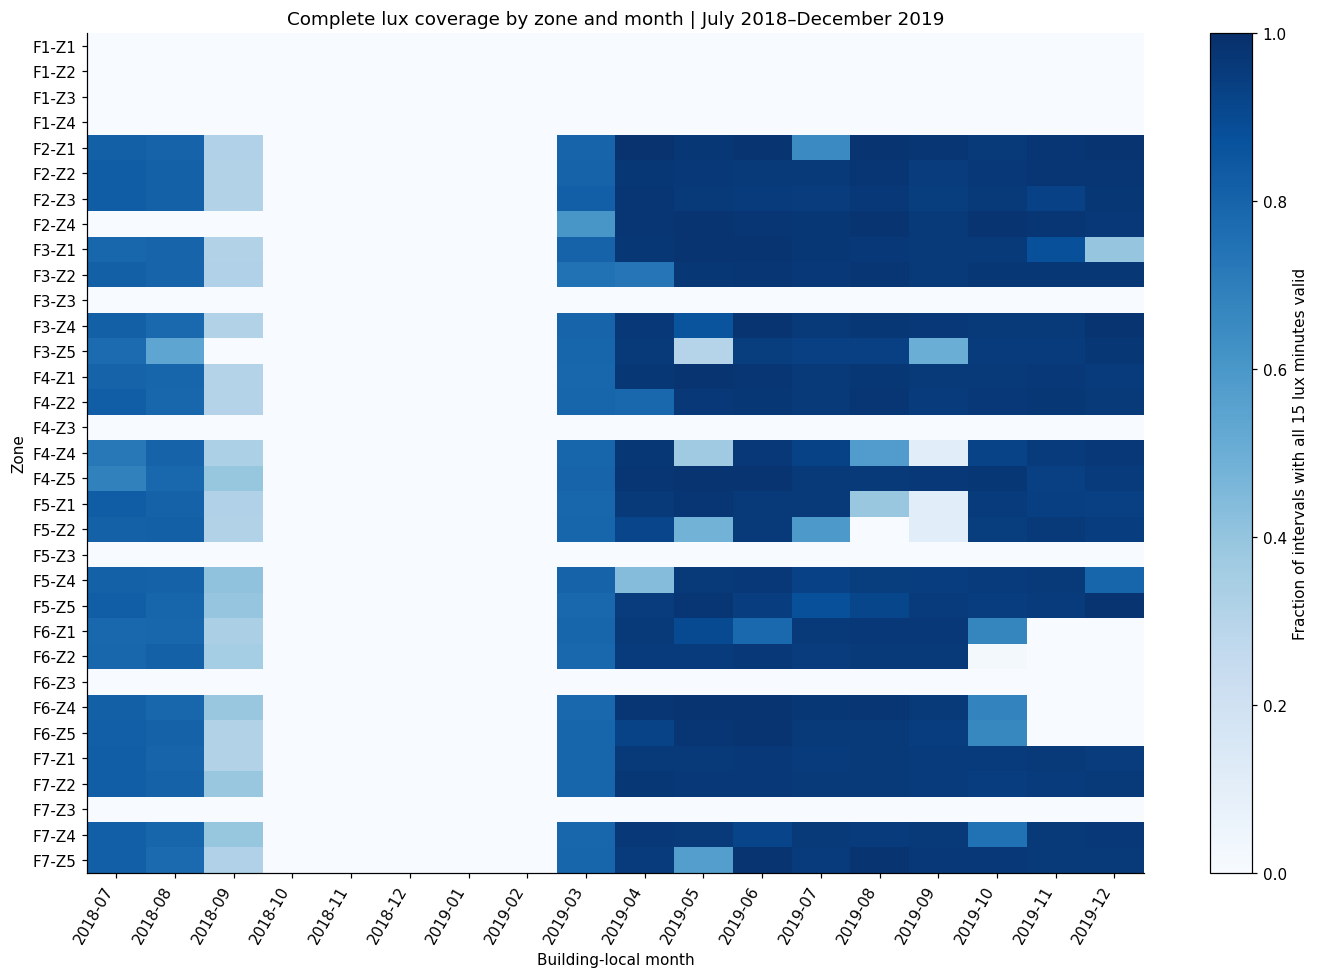

In [13]:
display(quality.groupby('kind').agg(channels=('column', 'size'),
        mean_missing_fraction=('missing_fraction', 'mean'),
        invalid_values=('invalid_values_masked', 'sum'),
        parse_failures=('numeric_parse_failures', 'sum'),
        high_outlier_flags=('high_outlier_flags', 'sum')))
display(quality.sort_values('missing_fraction', ascending=False).head(12))
monthly = panel.assign(month=panel.timestamp.dt.to_period('M').astype(str))
monthly_coverage = monthly.groupby(['zone_id', 'month']).agg(
    power_coverage=('total_kw', lambda s: s.notna().mean()),
    full_lux_coverage=('lux_min', lambda s: s.notna().mean()))
monthly_coverage.to_csv(OUT / 'monthly_coverage.csv')
matrix = monthly_coverage.full_lux_coverage.unstack('month')
fig, ax = plt.subplots(figsize=(13, 9))
image = ax.imshow(matrix.values, aspect='auto', vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=60, ha='right')
ax.set_yticks(range(len(matrix.index)), matrix.index)
ax.set(title='Complete lux coverage by zone and month | July 2018–December 2019',
       xlabel='Building-local month', ylabel='Zone')
ax.grid(False)
fig.colorbar(image, ax=ax, label='Fraction of intervals with all 15 lux minutes valid')
fig.tight_layout(); fig.savefig(OUT / '01_lux_coverage.png'); plt.show()

## Results
### 7. Annual zone baseline: peak demand, load mix, coverage, and lux
Annual energy is **observed kWh**, not a complete-year estimate. Annual maxima are observed
maxima; outages can hide a higher true maximum. Lighting's contribution at the peak limits
the leverage of a lighting-only intervention.

,zone_id,year,floor,expected_intervals,valid_power_intervals,power_coverage_fraction,observed_peak_kw,p95_kw,...,lighting_kw_at_peak,lighting_share_at_peak,observed_kwh,operating_intervals,full_lux_operating_intervals,operating_lux_coverage_fraction,measured_below_lux_fraction,measured_median_min_lux
4,F1-Z3,2018,1,17664,17470,0.989,332.387,53.541,...,330.611,0.995,"108,924.883",5240,0,0.000,NaN,NaN
3,F1-Z2,2019,1,35040,34765,0.992,146.400,105.913,...,36.981,0.253,"488,444.375",10440,0,0.000,NaN,NaN
2,F1-Z2,2018,1,17664,15399,0.872,132.956,97.286,...,18.164,0.137,"252,616.641",5240,0,0.000,NaN,NaN
5,F1-Z3,2019,1,35040,34879,0.995,76.369,45.581,...,75.907,0.994,"193,855.250",10440,0,0.000,NaN,NaN
0,F1-Z1,2018,1,17664,17469,0.989,71.630,32.408,...,50.144,0.700,"46,486.715",5240,0,0.000,NaN,NaN
6,F1-Z4,2018,1,17664,17576,0.995,65.690,52.551,...,65.690,1.000,"75,430.281",5240,0,0.000,NaN,NaN
7,F1-Z4,2019,1,35040,34994,0.999,57.930,46.652,...,57.930,1.000,"140,772.578",10440,0,0.000,NaN,NaN
1,F1-Z1,2019,1,35040,34706,0.990,56.897,21.749,...,43.753,0.769,"69,219.273",10440,0,0.000,NaN,NaN
9,F2-Z1,2019,2,35040,33037,0.943,55.470,46.959,...,8.415,0.152,"101,707.852",10440,8111,0.777,1.000,71.000
8,F2-Z1,2018,2,17664,17618,0.997,53.041,43.708,...,8.899,0.168,"55,060.516",5240,1677,0.320,1.000,78.000


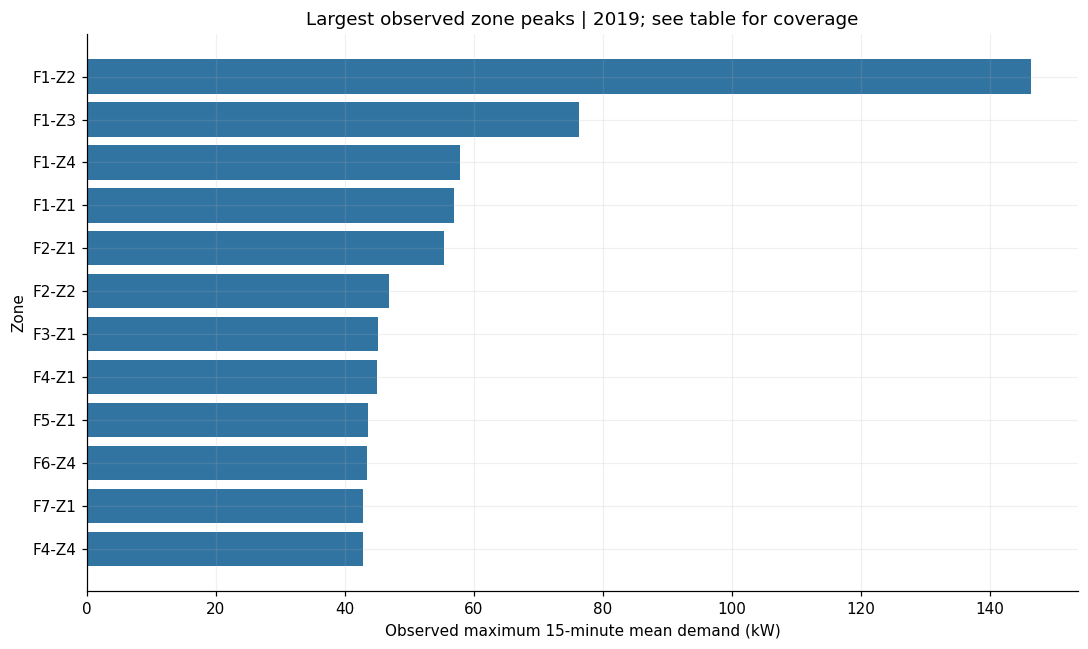

In [14]:
baseline = annual_eda(panel, COMFORT_LUX)
display(baseline.sort_values('observed_peak_kw', ascending=False).head(12))
baseline.to_csv(OUT / 'annual_zone_baseline.csv', index=False)
top = baseline.loc[baseline.year.eq(2019)].sort_values('observed_peak_kw').tail(12)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.zone_id, top.observed_peak_kw, color=BLUE)
ax.set(xlabel='Observed maximum 15-minute mean demand (kW)', ylabel='Zone',
       title='Largest observed zone peaks | 2019; see table for coverage')
ax.set_xlim(left=0); fig.tight_layout(); fig.savefig(OUT / '02_zone_peaks.png'); plt.show()

### 8. Pilot floor demand profile, time patterns, and load composition

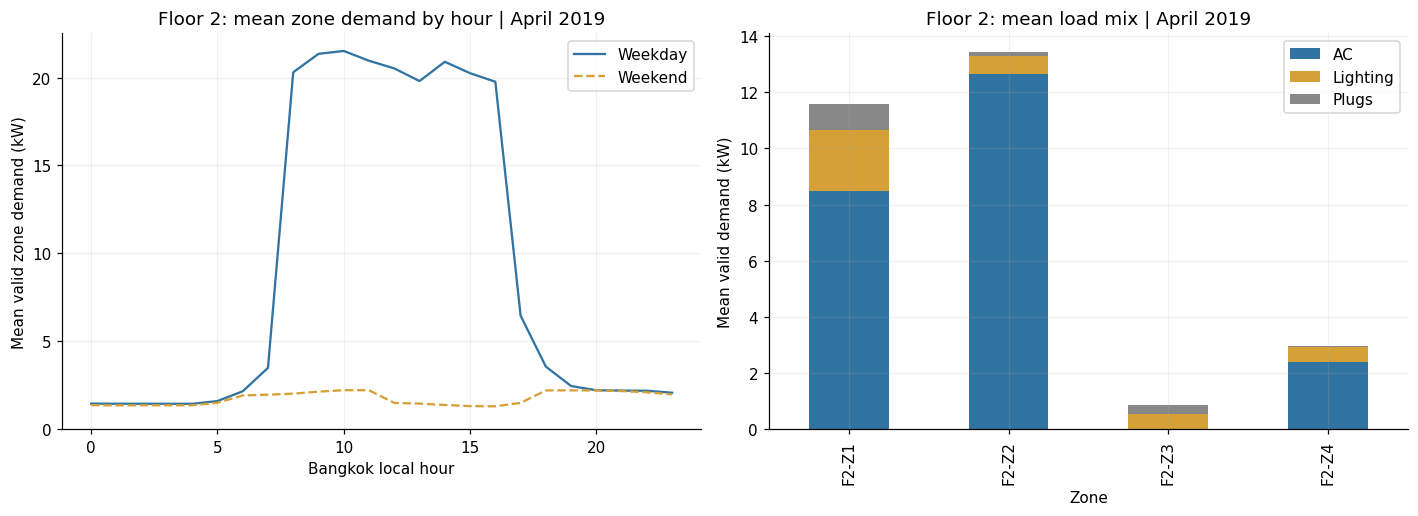

In [15]:
pilot = panel.loc[panel.floor.eq(PILOT_FLOOR) & panel.timestamp.ge(TEST_START) &
                  panel.timestamp.lt(TEST_END)].copy()
pilot['hour'] = pilot.timestamp.dt.hour
pilot['day_type'] = np.where(pilot.timestamp.dt.dayofweek < 5, 'Weekday', 'Weekend')
profile = pilot.groupby(['hour', 'day_type']).total_kw.mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for label, color, style in [('Weekday', BLUE, '-'), ('Weekend', GOLD, '--')]:
    if label in profile:
        axes[0].plot(profile.index, profile[label], label=label, color=color, linestyle=style)
axes[0].set(title=f'Floor {PILOT_FLOOR}: mean zone demand by hour | April 2019',
            xlabel='Bangkok local hour', ylabel='Mean valid zone demand (kW)', ylim=(0, None))
axes[0].legend()
# Shared complete-power rows for all three component means, to preserve additivity.
mix = pilot.loc[pilot.total_kw.notna()].groupby('zone_id')[['ac_kw','light_kw','plug_kw']].mean()
mix.plot.bar(stacked=True, color=[BLUE, GOLD, '#888888'], ax=axes[1])
axes[1].set(title=f'Floor {PILOT_FLOOR}: mean load mix | April 2019',
            ylabel='Mean valid demand (kW)', xlabel='Zone')
axes[1].legend(['AC', 'Lighting', 'Plugs'])
fig.tight_layout(); fig.savefig(OUT / '03_pilot_profiles.png'); plt.show()

### 9. Pilot lux versus lighting: measured comfort risk and observational relationship
Use raw minutes here. A high lux reading with lights on identifies screening headroom;
it does not isolate daylight. Correlation cannot identify the causal kW-to-lux response.
Temperature and humidity are excluded from the analysis because they do not quantify lighting-only reductions.

,count,mean,std,min,5%,50%,95%,max
total_kw,"13,156.000",36.392,20.591,0.010,0.060,45.005,54.440,58.910
ac_kw,"13,156.000",27.479,16.713,0.000,0.000,33.530,43.080,46.550
light_kw,"13,197.000",6.391,3.115,0.000,0.010,7.960,8.630,10.000
plug_kw,"13,197.000",2.494,1.295,0.000,0.050,3.160,3.600,4.570
lux,"13,141.000",62.372,29.262,0.000,3.000,78.000,85.000,89.000


Valid raw-minute lux fraction during assumed hours: 0.995530303030303
Below-target fraction among measured operating minutes: 1.0


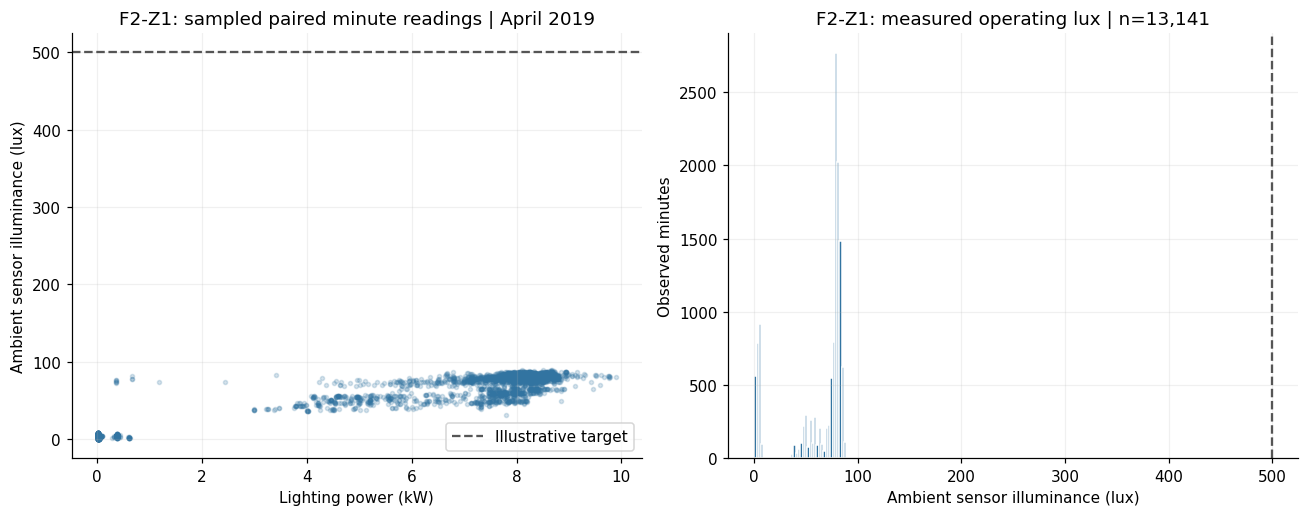

In [16]:
zone_options = sorted(pilot_minute.zone_id.unique())
PILOT_ZONE = f'F{PILOT_FLOOR}-Z1'
raw_zone = pilot_minute.loc[pilot_minute.zone_id.eq(PILOT_ZONE)].set_index('timestamp')
op_zone = raw_zone.loc[operating_mask(raw_zone.index)]
paired = op_zone[['light_kw', 'lux']].dropna()
display(op_zone[['total_kw','ac_kw','light_kw','plug_kw','lux']]
        .describe(percentiles=[.05,.5,.95]).T)
print('Valid raw-minute lux fraction during assumed hours:', op_zone.lux.notna().mean())
print('Below-target fraction among measured operating minutes:', op_zone.lux.dropna().lt(COMFORT_LUX).mean())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
if len(paired) >= 20:
    sample = paired.sample(min(5000, len(paired)), random_state=42)
    axes[0].scatter(sample.light_kw, sample.lux, s=7, alpha=.2, color=BLUE)
    axes[0].axhline(COMFORT_LUX, color=GREY, linestyle='--', label='Illustrative target')
    axes[0].legend()
else:
    axes[0].text(.5,.5,'Insufficient paired measurements', ha='center', transform=axes[0].transAxes)
axes[0].set(title=f'{PILOT_ZONE}: sampled paired minute readings | April 2019',
            xlabel='Lighting power (kW)', ylabel='Ambient sensor illuminance (lux)')
measured = op_zone.lux.dropna()
axes[1].hist(measured, bins=40, color=BLUE, edgecolor='white')
axes[1].axvline(COMFORT_LUX, color=GREY, linestyle='--')
axes[1].set(title=f'{PILOT_ZONE}: measured operating lux | n={len(measured):,}',
            xlabel='Ambient sensor illuminance (lux)', ylabel='Observed minutes')
fig.tight_layout(); fig.savefig(OUT / '04_pilot_lux.png'); plt.show()

### 10. Main answer table: conditional lighting-only peak reduction by zone
The trigger is the March 95th percentile of weekday operating zone demand, with at least
200 valid training intervals. Dim at most 20% only when April demand exceeds this trigger
and full interval lux stays above 550 lux (500 target plus 10% margin).

Baseline/scenario maxima use identical valid April power rows. No-lux zones get **no simulated
action**, not a claim of zero physical potential. A zero reduction can also mean the maximum
occurred outside operating hours or headroom was unavailable at the actual peak.

Use `supported_peak_reduction_kw` for the business-answer table. `conditional_peak_reduction_kw` is only the no-action/screening trace calculation; an unsupported zone must not be described as having zero achievable potential. Floor 2 is an illustrative study floor selected for manageable scope and sensor availability, not because savings were known in advance.

In [17]:
scenario, traces = screen_scenario(panel, COMFORT_LUX, LUX_MARGIN, DIM_CAP,
                                  TRAIN_START, TRAIN_END, TEST_START, TEST_END, PEAK_QUANTILE)
ranked = scenario.sort_values('conditional_peak_reduction_kw', ascending=False)
display(ranked[['zone_id','baseline_coverage_fraction','baseline_peak_kw','scenario_peak_kw',
                'supported_peak_reduction_kw','supported_peak_reduction_pct','assessment_supported',
                'saved_kw_at_baseline_peak','active_intervals','measured_below_target_fraction','status']])
scenario.to_csv(OUT / 'zone_peak_scenarios.csv', index=False)
# Detailed trace for the pilot floor keeps exported output manageable.
traces.loc[traces.floor.eq(PILOT_FLOOR)].to_csv(OUT / 'pilot_scenario_trace.csv', index=False)
positive = ranked.loc[ranked.conditional_peak_reduction_kw.gt(1e-7)]
if len(positive):
    top = positive.head(10).sort_values('conditional_peak_reduction_kw')
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.zone_id, top.conditional_peak_reduction_kw, color=BLUE)
    ax.set(title='Conditional zone peak reduction | April 2019; 500 lux, 20% cap',
           xlabel='Baseline maximum minus recomputed scenario maximum (kW)', ylabel='Zone', xlim=(0,None))
    fig.tight_layout(); fig.savefig(OUT / '05_conditional_reduction.png'); plt.show()
else:
    print('No positive conditional zone peak reductions. Do not rank tied zero savings.')
    print('Pilot lighting leverage at the observed peak (ignores comfort; not safe savings):')
    display(scenario.loc[scenario.floor.eq(PILOT_FLOOR),
        ['zone_id','baseline_peak_kw','lighting_kw_at_baseline_peak',
         'unrestricted_lighting_only_peak_ceiling_kw','status']])

,zone_id,baseline_coverage_fraction,baseline_peak_kw,scenario_peak_kw,supported_peak_reduction_kw,supported_peak_reduction_pct,assessment_supported,saved_kw_at_baseline_peak,active_intervals,measured_below_target_fraction,status
0,F1-Z1,0.999,45.859,45.859,NaN,NaN,False,0.000,0,NaN,Unavailable: no lux sensor
17,F4-Z5,0.970,22.792,22.792,0.000,0.000,True,0.000,0,1.000,Screened: no measured headroom at triggered in...
31,F7-Z4,0.933,39.329,39.329,NaN,NaN,False,0.000,0,1.000,Unavailable: incomplete April power baseline
30,F7-Z3,0.972,0.594,0.594,NaN,NaN,False,0.000,0,NaN,Unavailable: no lux sensor
29,F7-Z2,0.990,34.168,34.168,0.000,0.000,True,0.000,0,1.000,Screened: no measured headroom at triggered in...
28,F7-Z1,0.952,42.728,42.728,0.000,0.000,True,0.000,0,1.000,Screened: no measured headroom at triggered in...
27,F6-Z5,0.948,22.494,22.494,NaN,NaN,False,0.000,0,1.000,Unavailable: incomplete April power baseline
26,F6-Z4,0.990,43.388,43.388,0.000,0.000,True,0.000,0,1.000,Screened: no measured headroom at triggered in...
25,F6-Z3,1.000,2.823,2.823,NaN,NaN,False,0.000,0,NaN,Unavailable: no lux sensor
24,F6-Z2,0.999,33.493,33.493,0.000,0.000,True,0.000,0,1.000,Screened: no measured headroom at triggered in...


No positive conditional zone peak reductions. Do not rank tied zero savings.
Pilot lighting leverage at the observed peak (ignores comfort; not safe savings):


,zone_id,baseline_peak_kw,lighting_kw_at_baseline_peak,unrestricted_lighting_only_peak_ceiling_kw,status
4,F2-Z1,55.470,8.415,8.361,Screened: no measured headroom at triggered in...
5,F2-Z2,46.938,2.650,2.650,Screened: no measured headroom at triggered in...
6,F2-Z3,2.097,1.097,1.097,Screened: no measured headroom at triggered in...
7,F2-Z4,13.095,1.850,1.750,Screened: no measured headroom at triggered in...


### 11. Coincident building and pilot-floor peaks
Always align timestamps before summing. Summing individual zone maximum reductions is not
building peak reduction. These are totals of available submeters, not an audited utility-meter total.
The executed table reports complete all-zone intervals out of the full expected April calendar;
low complete-zone coverage means the supported-subset maximum **cannot establish the monthly building peak**.

,scope,complete_intervals,expected_intervals,complete_coverage_fraction,status,observed_submeter_peak_kw,scenario_submeter_peak_kw,conditional_coincident_reduction_kw
0,All observed zones,8,2880,0.003,Insufficient coverage for a monthly building-p...,156.166,156.166,0.000
1,Floor 2,2865,2880,0.995,Observed supported intervals only,114.824,114.824,0.000


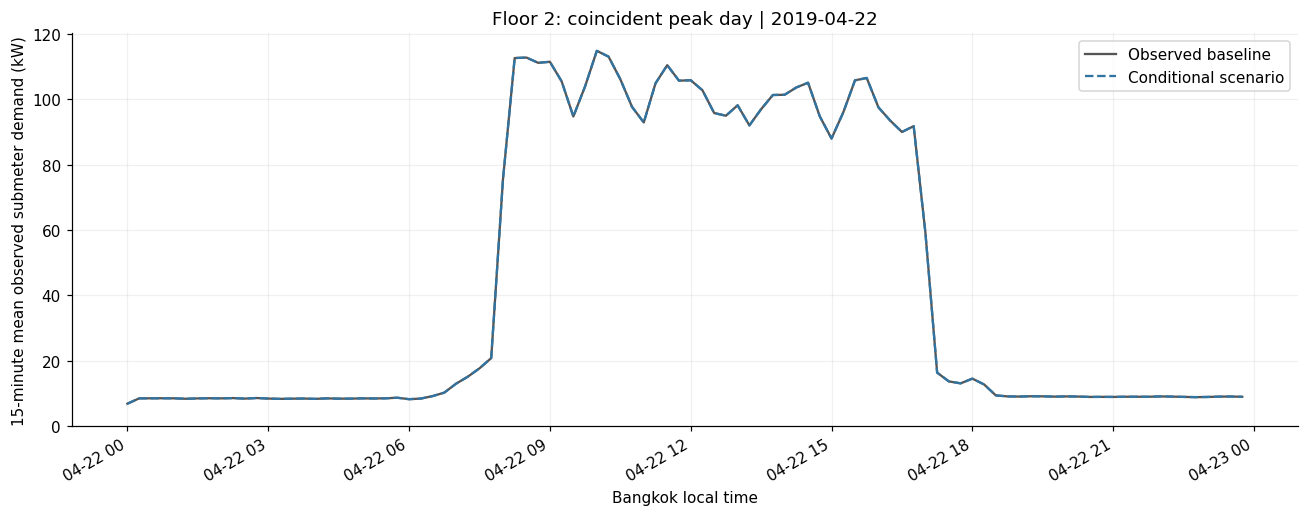

In [18]:
expected_test_intervals = int((pd.Timestamp(TEST_END)-pd.Timestamp(TEST_START))/pd.Timedelta(minutes=15))
coincident, coincident_summary = coincident_demand(traces, sorted(panel.zone_id.unique()), expected_test_intervals)
pilot_trace = traces.loc[traces.floor.eq(PILOT_FLOOR)]
floor_coincident, floor_summary = coincident_demand(pilot_trace, sorted(pilot.zone_id.unique()), expected_test_intervals)
display(pd.DataFrame([{'scope':'All observed zones', **coincident_summary},
                      {'scope':f'Floor {PILOT_FLOOR}', **floor_summary}]))
coincident.to_csv(OUT / 'coincident_submeter_demand.csv')
with (OUT / 'coincident_summary.json').open('w') as f:
    json.dump({'building_observed_submeters':coincident_summary, 'pilot_floor':floor_summary}, f, indent=2)
if len(floor_coincident):
    peak_day = floor_coincident.baseline_kw.idxmax().normalize()
    day = floor_coincident.loc[peak_day:peak_day+pd.Timedelta(days=1)-pd.Timedelta(minutes=1)]
    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.plot(day.index, day.baseline_kw, color=GREY, label='Observed baseline')
    ax.plot(day.index, day.scenario_kw, color=BLUE, linestyle='--', label='Conditional scenario')
    ax.set(title=f'Floor {PILOT_FLOOR}: coincident peak day | {peak_day.date()}',
           xlabel='Bangkok local time', ylabel='15-minute mean observed submeter demand (kW)', ylim=(0,None))
    ax.legend(); fig.autofmt_xdate(); fig.tight_layout()
    fig.savefig(OUT / '06_peak_day.png'); plt.show()

### 12. Sensitivity: task targets, dimming caps, and operating schedule
These are assumption scenarios, **not confidence intervals**. Lack of observed interventions
prevents a defensible causal uncertainty interval for achieved peak savings.

In [19]:
sensitivity_rows = []
for target in [300, 500, 750]:
    for cap in [.10, .20, .30]:
        table, trace = screen_scenario(panel, target, LUX_MARGIN, cap,
                                      TRAIN_START, TRAIN_END, TEST_START, TEST_END, PEAK_QUANTILE)
        _, simultaneous = coincident_demand(trace, sorted(panel.zone_id.unique()), expected_test_intervals)
        for row in table.itertuples():
            sensitivity_rows.append({'zone_id':row.zone_id,'target_lux':target,'dimming_cap':cap,
                'conditional_peak_reduction_kw':row.conditional_peak_reduction_kw,
                'supported_peak_reduction_kw':row.supported_peak_reduction_kw,
                'assessment_supported':row.assessment_supported,
                'active_intervals':row.active_intervals,
                'coincident_building_reduction_kw':simultaneous.get('conditional_coincident_reduction_kw', np.nan)})
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(OUT / 'sensitivity.csv', index=False)
display(sensitivity.loc[sensitivity.zone_id.eq(PILOT_ZONE)])
# Schedule sensitivity affects EDA comfort-risk denominator only; no occupancy is inferred.
schedule_rows = []
for start_hour, end_hour in [(8,18),(9,17),(7,19)]:
    lux = raw_zone.loc[operating_mask(raw_zone.index,start_hour,end_hour), 'lux'].dropna()
    schedule_rows.append({'assumed_hours':f'{start_hour}:00-{end_hour}:00',
                          'measured_minutes':len(lux),'below_target_fraction':lux.lt(COMFORT_LUX).mean()})
display(pd.DataFrame(schedule_rows))

,zone_id,target_lux,dimming_cap,conditional_peak_reduction_kw,supported_peak_reduction_kw,assessment_supported,active_intervals,coincident_building_reduction_kw
4,F2-Z1,300,0.100,0.000,0.000,True,0,0.000
37,F2-Z1,300,0.200,0.000,0.000,True,0,0.000
70,F2-Z1,300,0.300,0.000,0.000,True,0,0.000
103,F2-Z1,500,0.100,0.000,0.000,True,0,0.000
136,F2-Z1,500,0.200,0.000,0.000,True,0,0.000
169,F2-Z1,500,0.300,0.000,0.000,True,0,0.000
202,F2-Z1,750,0.100,0.000,0.000,True,0,0.000
235,F2-Z1,750,0.200,0.000,0.000,True,0,0.000
268,F2-Z1,750,0.300,0.000,0.000,True,0,0.000


,assumed_hours,measured_minutes,below_target_fraction
0,8:00-18:00,13141,1.000
1,9:00-17:00,10502,1.000
2,7:00-19:00,15781,1.000


### 13. Peak quality review and calculation checks
Inspect extreme peak minutes before choosing a pilot. Do not silently remove an unexplained
spike; if a facilities review identifies a meter fault, rerun and report the alternative cleaning policy.

In [20]:
display(quality.loc[quality.kind.isin(['ac','light','plug'])]
        .sort_values('maximum', ascending=False)[['file','column','median','p99','maximum','high_outlier_flags']].head(12))
peak_minutes = raw_zone.total_kw.nlargest(12).index
display(raw_zone.loc[peak_minutes, ['total_kw','ac_kw','light_kw','plug_kw','lux']])
assert not panel.duplicated(['timestamp','zone_id']).any()
complete_components = traces[['ac_kw','light_kw','plug_kw','total_kw']].dropna()
np.testing.assert_allclose(complete_components[['ac_kw','light_kw','plug_kw']].sum(axis=1),
                           complete_components.total_kw, rtol=2e-5, atol=1e-4)
assert (scenario.conditional_peak_reduction_kw >= -1e-7).all()
assert (scenario.conditional_peak_reduction_kw <=
        scenario.unrestricted_lighting_only_peak_ceiling_kw+1e-5).all()
assert scenario.proxy_below_guard_active_intervals.sum() == 0
assert traces.loc[~traces.has_lux_sensor,'saved_kw'].eq(0).all()
assert traces.loc[traces.lux_valid_minutes.lt(15),'saved_kw'].eq(0).all()
assert traces.loc[traces.power_valid_minutes.lt(15),'saved_kw'].eq(0).all()
print('Checks passed: unique grain, component reconciliation, bounded savings, missing-data safeguards.')
assert scenario.loc[~scenario.assessment_supported, 'supported_peak_reduction_kw'].isna().all()
assert scenario.proven_comfort_preserving_reduction_kw.isna().all()
assert traces.loc[~traces.peak_event, 'saved_kw'].eq(0).all()
assert traces.loc[traces.lux_min.isna(), 'saved_kw'].eq(0).all()
assert traces.power_valid_minutes.eq(15).all()
# Known-answer check: shaving the original 10 kW maximum by 1 kW relocates it to 9.5 kW.
synthetic_before = pd.Series([10., 9.5, 9.])
synthetic_cut = pd.Series([1., 0., .2])
assert np.isclose(synthetic_before.max()-(synthetic_before-synthetic_cut).max(), .5)
# Ambiguous date strings must not be guessed.
assert parse_dates(pd.Series(['1/2/19 0:00','13/2/19 0:00'])).iloc[0] == pd.Timestamp('2019-02-01')
try:
    parse_dates(pd.Series(['1/2/19 0:00']))
    raise AssertionError('Ambiguous dates were accepted')
except ValueError:
    pass
print('Additional checks passed: unavailable estimates, peak-only action, complete intervals, date convention and peak relocation.')

,file,column,median,p99,maximum,high_outlier_flags
8,2018Floor1.csv,z3_Light(kW),20.770,76.920,"4,762.430",5071
3,2018Floor1.csv,z2_AC2(kW),0.020,39.970,798.720,53616
10,2018Floor1.csv,z4_Light(kW),9.910,59.310,512.010,1
57,2018Floor3.csv,z2_Light(kW),0.000,6.660,236.160,10
257,2019Floor3.csv,z4_Light(kW),0.000,3.090,186.080,48
263,2019Floor3.csv,z5_Light(kW),0.000,2.800,172.320,40
51,2018Floor3.csv,z1_Light(kW),0.000,5.780,162.240,10
0,2018Floor1.csv,z1_Light(kW),0.020,44.920,134.970,35
2,2018Floor1.csv,z2_AC1(kW),44.280,52.330,131.550,0
200,2019Floor1.csv,z3_Light(kW),18.190,55.790,105.670,13530


,total_kw,ac_kw,light_kw,plug_kw,lux
timestamp,,,,,
2019-04-22 14:21:00,58.910,45.580,9.290,4.040,80.000
2019-04-01 10:35:00,58.760,46.550,8.670,3.540,82.000
2019-04-17 15:55:00,57.650,46.240,8.410,3.000,79.000
2019-04-01 13:14:00,57.360,45.400,8.690,3.270,80.000
2019-04-18 16:17:00,57.120,46.150,8.150,2.820,68.000
2019-04-01 15:15:00,57.110,44.760,8.760,3.590,76.000
2019-04-17 14:48:00,56.860,43.310,9.740,3.810,81.000
2019-04-22 10:22:00,56.820,43.500,9.290,4.030,84.000
2019-04-22 14:22:00,56.820,45.420,8.050,3.350,80.000


Checks passed: unique grain, component reconciliation, bounded savings, missing-data safeguards.
Additional checks passed: unavailable estimates, peak-only action, complete intervals, date convention and peak relocation.


## Takeaways
### 14. Evidence-based shortlist and final interpretation
The following text is generated from executed results. Report each zone's table entry rather
than extrapolating one zone to the building. A high existing below-target fraction is a reason
to investigate lighting provision before a dimming pilot.

In [21]:
sensor_zones = int(zone_map.get('lux', pd.Series(dtype=float)).gt(0).sum())
print(f'Observed zones: {panel.zone_id.nunique()}; zones with lux columns: {sensor_zones}.')
print(f'Maximum valid lux across all input files: {quality.loc[quality.kind.eq("lux"), "maximum"].max():.1f}.')
positive = ranked.loc[ranked.supported_peak_reduction_kw.gt(1e-7)]
print(f'{int(scenario.assessment_supported.sum())} zones pass the April assessment gates; others have unavailable supported estimates.')
print(f'{len(positive)} zones have a positive conditional April peak reduction under the default assumptions.')
for row in positive.head(5).itertuples():
    print(f'{row.zone_id}: {row.conditional_peak_reduction_kw:.2f} kW '
          f'({row.conditional_peak_reduction_pct:.2f}%) conditional peak reduction; '
          f'{row.active_intervals} action intervals; '
          f'{100*row.measured_below_target_fraction:.1f}% below-target measured operating intervals.')
print('Coincident observed-submeter scenario:', coincident_summary)
print('Proven comfort-preserving achievable reduction: not identified from observational data.')
print('Use the shortlist to choose a field trial, not to issue a savings guarantee.')
parameters = dict(interval_minutes=INTERVAL_MINUTES, coverage=MIN_COVERAGE, target_lux=COMFORT_LUX,
                  lux_margin=LUX_MARGIN, dim_cap=DIM_CAP, train_start=TRAIN_START, train_end=TRAIN_END,
                  test_start=TEST_START, test_end=TEST_END, peak_quantile=PEAK_QUANTILE,
                  timezone='Asia/Bangkok (assumed local clock)', operating_hours='Weekdays 08:00-18:00')
(OUT / 'analysis_parameters.json').write_text(json.dumps(parameters, indent=2))
print('Export folder:', OUT)

Observed zones: 33; zones with lux columns: 24.
Maximum valid lux across all input files: 138.0.
14 zones pass the April assessment gates; others have unavailable supported estimates.
0 zones have a positive conditional April peak reduction under the default assumptions.
Coincident observed-submeter scenario: {'complete_intervals': 8, 'expected_intervals': 2880, 'complete_coverage_fraction': 0.002777777777777778, 'status': 'Insufficient coverage for a monthly building-peak claim', 'observed_submeter_peak_kw': 156.16592407226562, 'scenario_submeter_peak_kw': 156.16592407226562, 'conditional_coincident_reduction_kw': 0.0}
Proven comfort-preserving achievable reduction: not identified from observational data.
Use the shortlist to choose a field trial, not to issue a savings guarantee.
Export folder: /Users/xiangyingg/Documents/GitHub/IS4001-Smart-Building-Analytics/SBA_Kaggle_Dataset/Light/outputs/focused_april


### 15. Action and KPIs
**Pilot:** begin with a sensor-equipped zone on Floor 2 after reviewing its measured lux deficits,
sensor position, fixture dimmability, extreme power readings, and zone function. If Floor 2 is
unsuitable, select another sensor-equipped zone from the full-building shortlist. Record occupancy
and task-plane measurements; retain manual override. Test 10% dimming, then 20% only if safeguards pass.
Use real-time lux feedback; never deploy an interval-hindsight rule directly.

**Fair trial:** randomise eligible peak events to baseline/control and dimming, or use a
randomised switchback by day with the same zone, task schedule and peak windows. Freeze the trigger
before the trial. Record daylight context, occupancy, overrides, and sensor outages; use clustered
day-level uncertainty for trial estimates. Never compare different seasons without adjustment.

| KPI | Definition | Provisional pilot criterion |
|---|---|---|
| Zone demand reduction | Matched control minus treatment 15-minute mean kW at prespecified peak events | Positive estimate with uncertainty reported; set numeric target after calibration |
| Monthly peak demand | Control counterfactual maximum minus measured treatment maximum, same month/coverage | Report separately from event-average saving; requires credible counterfactual |
| Lighting comfort guardrail | Occupied task-plane minutes below approved zone target / valid occupied measured minutes | No increase relative to control; immediately revert on a measured task-plane breach |
| Lux completeness | Valid occupied task-plane minutes / expected occupied minutes | At least 95%; no automatic action on sensor failure |
| User experience | Comfort complaints / occupied person-hours; override events / treatment events | No increase vs control; review all overrides |
| Lighting energy | Measured/control lighting kWh over identical supported periods | Secondary benefit; distinguish kWh from peak kW |
| Coincident building demand | Maximum aligned observed main-meter/submeter total over trial period | Demonstrate that zone savings occur at building peak times |

Lux is one lighting-comfort guardrail. Inspect glare, uniformity and user comfort in the trial.
No complaint/occupancy KPIs can be populated from this dataset alone. No monetary KPI is calculated
without the verified tariff and utility demand interval.